In [1]:
import os 
import sys 
import re 
import yaml
import inspect 
import numpy as np 
import pandas as pd
import xarray as xr
from collections import defaultdict
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

In [13]:
#get path for USOS_shared directory for correct laptop
#input parameter should be 'CHPC', 'Mac', or 'Windows'
# current_dir = os.path.dirname(os.path.abspath(__file__))
# global_scripts_path = os.path.abspath(os.path.join(current_dir, "..", "global_scripts"))
# sys.path.insert(0,global_scripts_path)
# from dirpath import filepath_source
# dirpath = filepath_source('CHPC')
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

#define path for Hawthorne data directory
savepath= dirpath + 'Hawthorne_data/'

udaq_voc_filepath = dirpath + 'Hawthorne_data/Verbose.csv'
udaq_qc_voc_filepath = dirpath + 'Hawthorne_data/udaq_QC_07012024_08012024.csv'

In [119]:
#Read UDAQ VOC measurements file
df_data_qc = pd.read_csv(udaq_qc_voc_filepath) 
#Get only the data at Hawthorne
df_udaq_hawthornedates_usos_only_qc = df_data_qc.loc[(df_data_qc['StationSym'] == 'HW')]
#set index to datetimeindex
df_udaq_hawthornedates_usos_only_qc.set_index(['dt'], inplace = True) 
df_udaq_hawthornedates_usos_only_qc.index = pd.to_datetime(df_udaq_hawthornedates_usos_only_qc.index)

print(df_udaq_hawthornedates_usos_only_qc.index )
# #Get only the data during the USOS campaign
# df_udaq_hawthornedates_usos_only_qc = df_udaq_hawthornedates_usos_only_qc.sort_index().loc['2024-07-14 00:00:00':'2024-08-18 23:00:00']

/tmp/ipykernel_943819/78029375.py:2: DtypeWarning: Columns (5,14,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data_qc = pd.read_csv(udaq_qc_voc_filepath)


DatetimeIndex(['2024-07-01 00:00:00', '2024-07-01 01:00:00',
               '2024-07-01 02:00:00', '2024-07-01 03:00:00',
               '2024-07-01 04:00:00', '2024-07-01 05:00:00',
               '2024-07-01 06:00:00', '2024-07-01 07:00:00',
               '2024-07-01 08:00:00', '2024-07-01 09:00:00',
               ...
               '2024-08-01 14:00:00', '2024-08-01 15:00:00',
               '2024-08-01 16:00:00', '2024-08-01 17:00:00',
               '2024-08-01 18:00:00', '2024-08-01 19:00:00',
               '2024-08-01 20:00:00', '2024-08-01 21:00:00',
               '2024-08-01 22:00:00', '2024-08-01 23:00:00'],
              dtype='datetime64[ns]', name='dt', length=70656, freq=None)


In [16]:
display(df_udaq_hawthornedates_usos_only_qc.columns)

Index(['State Code', 'County Code', 'Site ID', 'Parameter', 'POC',
       'Sample Duration', 'Unit', 'Method', 'Date', 'Start Time',
       'Sample Value', 'Null Data Code', 'Qualifier - 1', 'Qualifier - 2',
       'Qualifier - 3', 'Alternate Method Detectable Limit', 'Uncertainty',
       'Station', 'StationSym', 'Latitude', 'Longitude', 'SiteName',
       'ParamMethod', 'AnalysisDescription', 'ParameterName',
       'ChemicalFormula', 'Sample End Time', 'Qualifier 1 Description',
       'Qualifier 2 Description', 'Qualifier 3 Description'],
      dtype='object')

In [107]:
parameter_codes_needed = [43243, 45201, 45202]
df_udaq_species_needed_qc = df_udaq_hawthornedates_usos_only_qc.loc[df_udaq_hawthornedates_usos_only_qc['Parameter'].isin(parameter_codes_needed)]
pd.set_option('display.max_rows', 800, 'display.min_rows', 800, 'display.max_columns', None)
#display(df_hawthorne_species_needed)
df_reshaped_udaq_species_qc = df_udaq_species_needed_qc.groupby([df_udaq_species_needed_qc.index, 'Parameter'])['Sample Value'].first().unstack()
print(df_reshaped_udaq_species_qc)

Parameter              43243   45201    45202
dt                                           
2024-07-14 00:00:00      NaN     NaN      NaN
2024-07-14 01:00:00      NaN     NaN      NaN
2024-07-14 02:00:00      NaN     NaN      NaN
2024-07-14 03:00:00      NaN     NaN      NaN
2024-07-14 04:00:00      NaN     NaN      NaN
2024-07-14 05:00:00      NaN     NaN      NaN
2024-07-14 06:00:00      NaN     NaN      NaN
2024-07-14 07:00:00      NaN     NaN      NaN
2024-07-14 08:00:00      NaN     NaN      NaN
2024-07-14 09:00:00      NaN     NaN      NaN
2024-07-14 10:00:00      NaN     NaN      NaN
2024-07-14 11:00:00      NaN     NaN      NaN
2024-07-14 12:00:00      NaN     NaN      NaN
2024-07-14 13:00:00   2.0633  0.1437   0.1148
2024-07-14 14:00:00      NaN     NaN      NaN
2024-07-14 15:00:00      NaN     NaN      NaN
2024-07-14 16:00:00   1.6178  0.1222   0.7745
2024-07-14 17:00:00   1.9728  3.3058  16.8700
2024-07-14 18:00:00   3.0619  1.3514   7.4946
2024-07-14 19:00:00  10.9391  2.48

In [108]:
display(df_reshaped_udaq_species_qc)

Parameter,43243,45201,45202
dt,,,
2024-07-14 00:00:00,NaN,NaN,NaN
2024-07-14 01:00:00,NaN,NaN,NaN
2024-07-14 02:00:00,NaN,NaN,NaN
2024-07-14 03:00:00,NaN,NaN,NaN
2024-07-14 04:00:00,NaN,NaN,NaN
2024-07-14 05:00:00,NaN,NaN,NaN
2024-07-14 06:00:00,NaN,NaN,NaN
2024-07-14 07:00:00,NaN,NaN,NaN
2024-07-14 08:00:00,NaN,NaN,NaN


In [128]:
# load file for all dates
all_days_filepath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_30min/all_CSL_MobileLab_Parked_rev30minv4.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.reset_index(inplace=True)
df_alldays.set_index('time_local', inplace=True, drop=False)
df_alldays['USOS O3'] = df_alldays['O3_ppbv']

In [131]:
print(df_alldays.index)

DatetimeIndex(['2024-07-14 18:00:00', '2024-07-14 18:30:00',
               '2024-07-14 19:00:00', '2024-07-14 19:30:00',
               '2024-07-14 20:00:00', '2024-07-14 20:30:00',
               '2024-07-14 21:00:00', '2024-07-14 21:30:00',
               '2024-07-14 22:00:00', '2024-07-14 22:30:00',
               ...
               '2024-08-18 13:00:00', '2024-08-18 13:30:00',
               '2024-08-18 14:00:00', '2024-08-18 14:30:00',
               '2024-08-18 15:00:00', '2024-08-18 15:30:00',
               '2024-08-18 16:00:00', '2024-08-18 16:30:00',
               '2024-08-18 17:00:00', '2024-08-18 17:30:00'],
              dtype='datetime64[ns]', name='time_local', length=1680, freq=None)


In [132]:
print(df_alldays['Isoprene_PTR'])

time_local
2024-07-14 18:00:00    0.701197
2024-07-14 18:30:00    0.245411
2024-07-14 19:00:00    0.175870
2024-07-14 19:30:00    0.621888
2024-07-14 20:00:00    1.211183
2024-07-14 20:30:00    3.098078
2024-07-14 21:00:00    4.306617
2024-07-14 21:30:00    2.916671
2024-07-14 22:00:00    1.954819
2024-07-14 22:30:00    1.226572
2024-07-14 23:00:00    0.863114
2024-07-14 23:30:00    0.414629
2024-07-15 00:00:00    0.043671
2024-07-15 00:30:00    0.017950
2024-07-15 01:00:00    0.031124
2024-07-15 01:30:00    0.047872
2024-07-15 02:00:00    0.140370
2024-07-15 02:30:00    0.167951
2024-07-15 03:00:00    0.178574
2024-07-15 03:30:00    0.190022
2024-07-15 04:00:00    0.193920
2024-07-15 04:30:00    0.215145
2024-07-15 05:00:00    0.181891
2024-07-15 05:30:00    0.201871
2024-07-15 06:00:00    0.241792
2024-07-15 06:30:00    0.268147
2024-07-15 07:00:00    0.378069
2024-07-15 07:30:00    0.452597
2024-07-15 08:00:00    0.510307
2024-07-15 08:30:00         NaN
2024-07-15 09:00:00         N

In [133]:
#adds padding of NaNs for first day and last day of campaign, since they need to have the same length of time as the other days in order to plot
new_start_time = pd.Timestamp('2024-07-14 00:00:00')
new_end_time = pd.Timestamp('2024-08-18 23:00:00')

# Create a new datetime index from new_start to the end of existing index with same frequency
new_index = pd.date_range(start=new_start_time, end=new_end_time, freq='1h')

# Reindex the dataframe to include new rows
df_alldays = df_alldays.reindex(new_index)
# Now df_expanded has rows starting at 00:00 with NaNs for the new rows

In [134]:
print(df_alldays['Isoprene_PTR'])

2024-07-14 00:00:00         NaN
2024-07-14 01:00:00         NaN
2024-07-14 02:00:00         NaN
2024-07-14 03:00:00         NaN
2024-07-14 04:00:00         NaN
2024-07-14 05:00:00         NaN
2024-07-14 06:00:00         NaN
2024-07-14 07:00:00         NaN
2024-07-14 08:00:00         NaN
2024-07-14 09:00:00         NaN
2024-07-14 10:00:00         NaN
2024-07-14 11:00:00         NaN
2024-07-14 12:00:00         NaN
2024-07-14 13:00:00         NaN
2024-07-14 14:00:00         NaN
2024-07-14 15:00:00         NaN
2024-07-14 16:00:00         NaN
2024-07-14 17:00:00         NaN
2024-07-14 18:00:00    0.701197
2024-07-14 19:00:00    0.175870
2024-07-14 20:00:00    1.211183
2024-07-14 21:00:00    4.306617
2024-07-14 22:00:00    1.954819
2024-07-14 23:00:00    0.863114
2024-07-15 00:00:00    0.043671
2024-07-15 01:00:00    0.031124
2024-07-15 02:00:00    0.140370
2024-07-15 03:00:00    0.178574
2024-07-15 04:00:00    0.193920
2024-07-15 05:00:00    0.181891
2024-07-15 06:00:00    0.241792
2024-07-

In [ ]:
#Read UDAQ VOC measurements file
df_data = pd.read_csv(udaq_voc_filepath) 
#Get only the data at Hawthorne
df_udaq_hawthornedates_usos_only = df_data.loc[(df_data['StationSym'] == 'HW')]
#set index to datetimeindex
df_udaq_hawthornedates_usos_only.set_index(['dt'], inplace = True) 
df_udaq_hawthornedates_usos_only.index = pd.to_datetime(df_udaq_hawthornedates_usos_only.index)

#Get only the data during the USOS campaign
df_udaq_hawthornedates_usos_only = df_udaq_hawthornedates_usos_only.sort_index().loc['2024-07-14 00:00:00':'2024-08-18 23:00:00']

/tmp/ipykernel_943819/1386785295.py:2: DtypeWarning: Columns (14,22,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data = pd.read_csv(udaq_voc_filepath)


DatetimeIndex(['2024-07-07 00:00:00', '2024-07-07 01:00:00',
               '2024-07-07 02:00:00', '2024-07-07 03:00:00',
               '2024-07-07 04:00:00', '2024-07-07 05:00:00',
               '2024-07-07 06:00:00', '2024-07-07 07:00:00',
               '2024-07-07 08:00:00', '2024-07-07 09:00:00',
               ...
               '2025-03-31 14:00:00', '2025-03-31 15:00:00',
               '2025-03-31 16:00:00', '2025-03-31 17:00:00',
               '2025-03-31 18:00:00', '2025-03-31 19:00:00',
               '2025-03-31 20:00:00', '2025-03-31 21:00:00',
               '2025-03-31 22:00:00', '2025-03-31 23:00:00'],
              dtype='datetime64[ns]', name='dt', length=373149, freq=None)
DatetimeIndex(['2024-07-14 00:00:00', '2024-07-14 00:00:00',
               '2024-07-14 00:00:00', '2024-07-14 00:00:00',
               '2024-07-14 00:00:00', '2024-07-14 00:00:00',
               '2024-07-14 00:00:00', '2024-07-14 00:00:00',
               '2024-07-14 00:00:00', '2024-07-14 0

In [ ]:
print(df_udaq_hawthornedates_usos_only)

In [123]:
df_usos_species_needed = ['Isoprene_PTR', 'Benzene_PTR', 'Toluene_PTR']
df_usos_species_locate = df_alldays.loc[:,df_usos_species_needed]
print(df_usos_species_locate)

                     Isoprene_PTR  Benzene_PTR  Toluene_PTR
2024-07-14 00:00:00           NaN          NaN          NaN
2024-07-14 01:00:00           NaN          NaN          NaN
2024-07-14 02:00:00           NaN          NaN          NaN
2024-07-14 03:00:00           NaN          NaN          NaN
2024-07-14 04:00:00           NaN          NaN          NaN
2024-07-14 05:00:00           NaN          NaN          NaN
2024-07-14 06:00:00           NaN          NaN          NaN
2024-07-14 07:00:00           NaN          NaN          NaN
2024-07-14 08:00:00           NaN          NaN          NaN
2024-07-14 09:00:00           NaN          NaN          NaN
2024-07-14 10:00:00           NaN          NaN          NaN
2024-07-14 11:00:00           NaN          NaN          NaN
2024-07-14 12:00:00           NaN          NaN          NaN
2024-07-14 13:00:00           NaN          NaN          NaN
2024-07-14 14:00:00           NaN          NaN          NaN
2024-07-14 15:00:00           NaN       

In [113]:
species_names = ['Isoprene', 'Benzene', 'Toluene']

In [126]:
#View Parameter code values as only an int (they print with a .0 at the end initially)
#Sort and only include the unique parameter codes
df_udaq_hawthornedates_usos_only.Parameter = df_udaq_hawthornedates_usos_only.Parameter.astype(int)
# sorted_parameters = sorted(df_hawthorne_usos_only.Parameter.unique())
# print(sorted_parameters)
#Correspond to:
#43243: isoprene
#45201: Benzene
#45202: Toluene
#45220: Styrene
parameter_codes_needed = [43243, 45201, 45202]
df_udaq_species_needed = df_udaq_hawthornedates_usos_only.loc[df_udaq_hawthornedates_usos_only['Parameter'].isin(parameter_codes_needed)]
pd.set_option('display.max_rows', 800, 'display.min_rows', 800, 'display.max_columns', None)
#display(df_udaq_species_needed)
df_reshaped_udaq_species = df_udaq_species_needed.groupby([df_udaq_species_needed.index, 'Parameter'])['Sample Value'].first().unstack()
print(df_reshaped_udaq_species)

Parameter              43243   45201    45202
dt                                           
2024-07-14 00:00:00      NaN     NaN      NaN
2024-07-14 01:00:00      NaN     NaN      NaN
2024-07-14 02:00:00      NaN     NaN      NaN
2024-07-14 03:00:00      NaN     NaN      NaN
2024-07-14 04:00:00      NaN     NaN      NaN
2024-07-14 05:00:00      NaN     NaN      NaN
2024-07-14 06:00:00      NaN     NaN      NaN
2024-07-14 07:00:00      NaN     NaN      NaN
2024-07-14 08:00:00      NaN     NaN      NaN
2024-07-14 09:00:00      NaN     NaN      NaN
2024-07-14 10:00:00      NaN     NaN      NaN
2024-07-14 11:00:00      NaN     NaN      NaN
2024-07-14 12:00:00      NaN     NaN      NaN
2024-07-14 13:00:00   2.0633  0.1437   0.1148
2024-07-14 14:00:00      NaN     NaN      NaN
2024-07-14 15:00:00      NaN     NaN      NaN
2024-07-14 16:00:00   1.6178  0.1222   0.7745
2024-07-14 17:00:00   1.9728  3.3058  16.8700
2024-07-14 18:00:00   3.0619  1.3514   7.4946
2024-07-14 19:00:00  10.9391  2.48

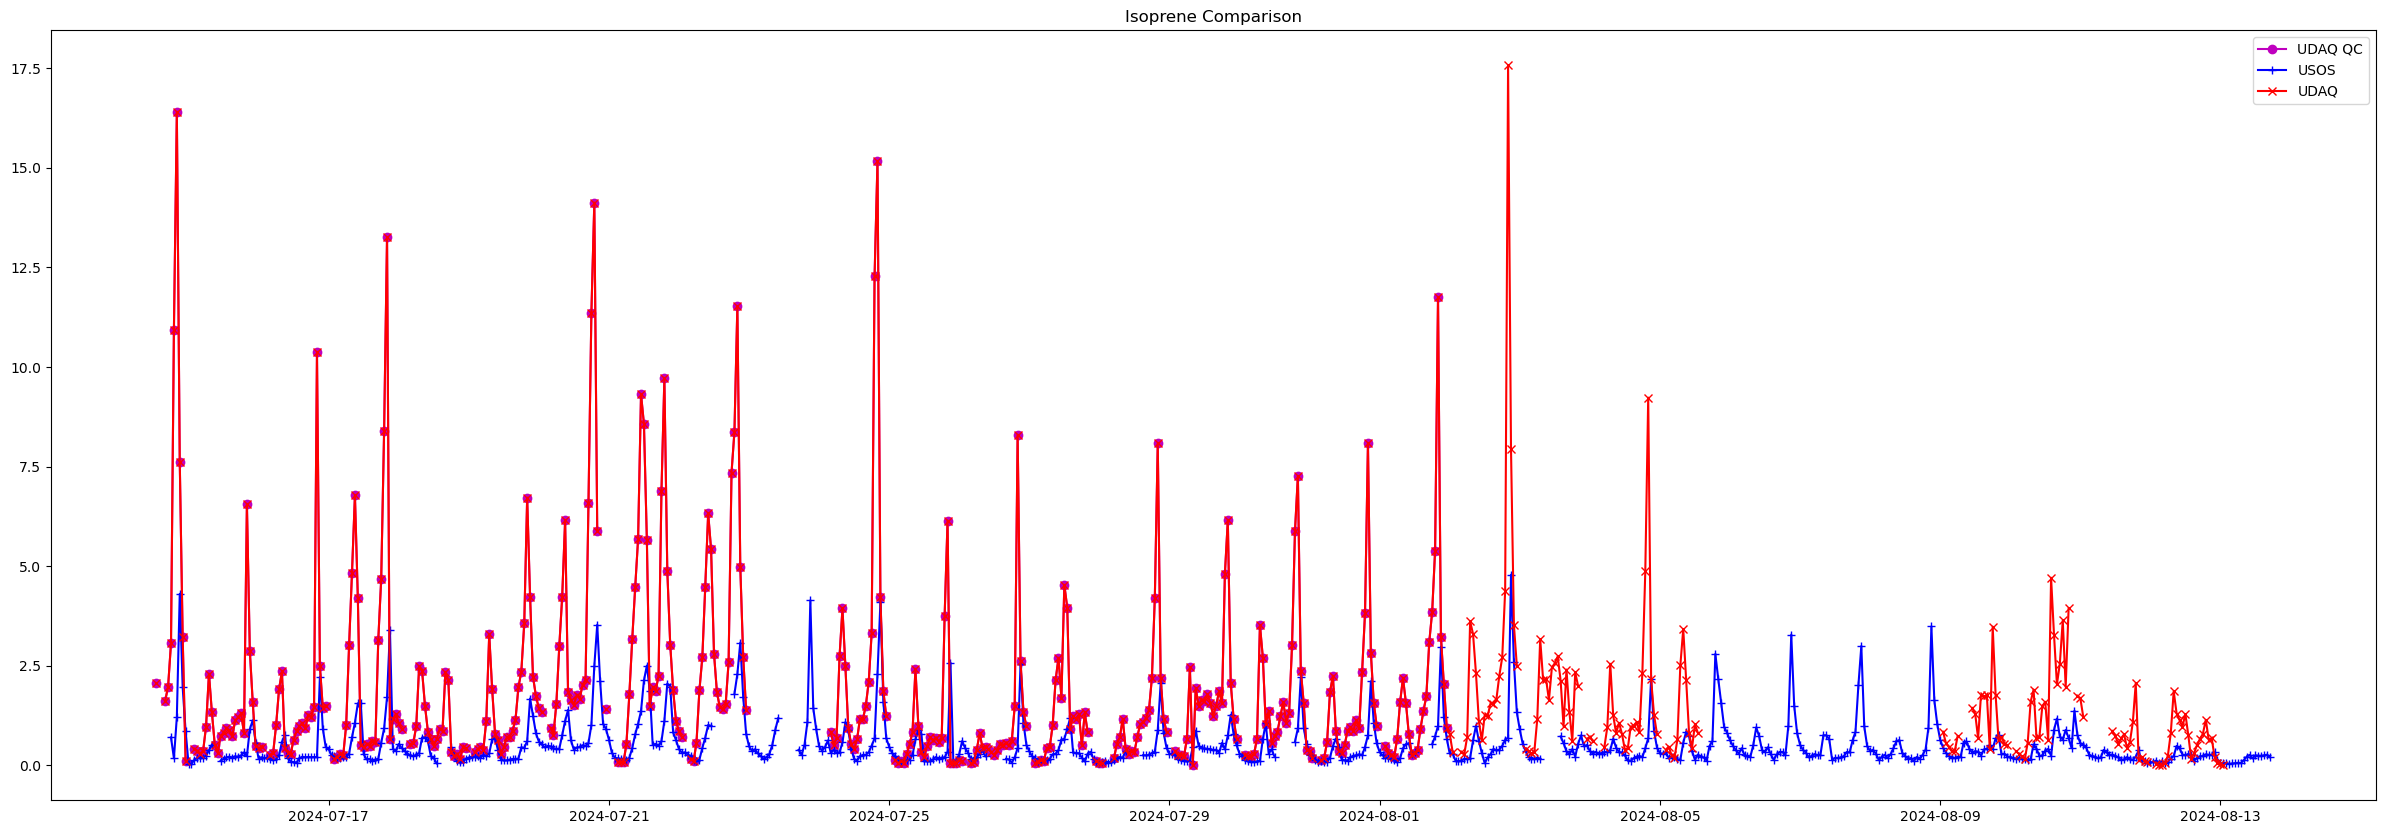

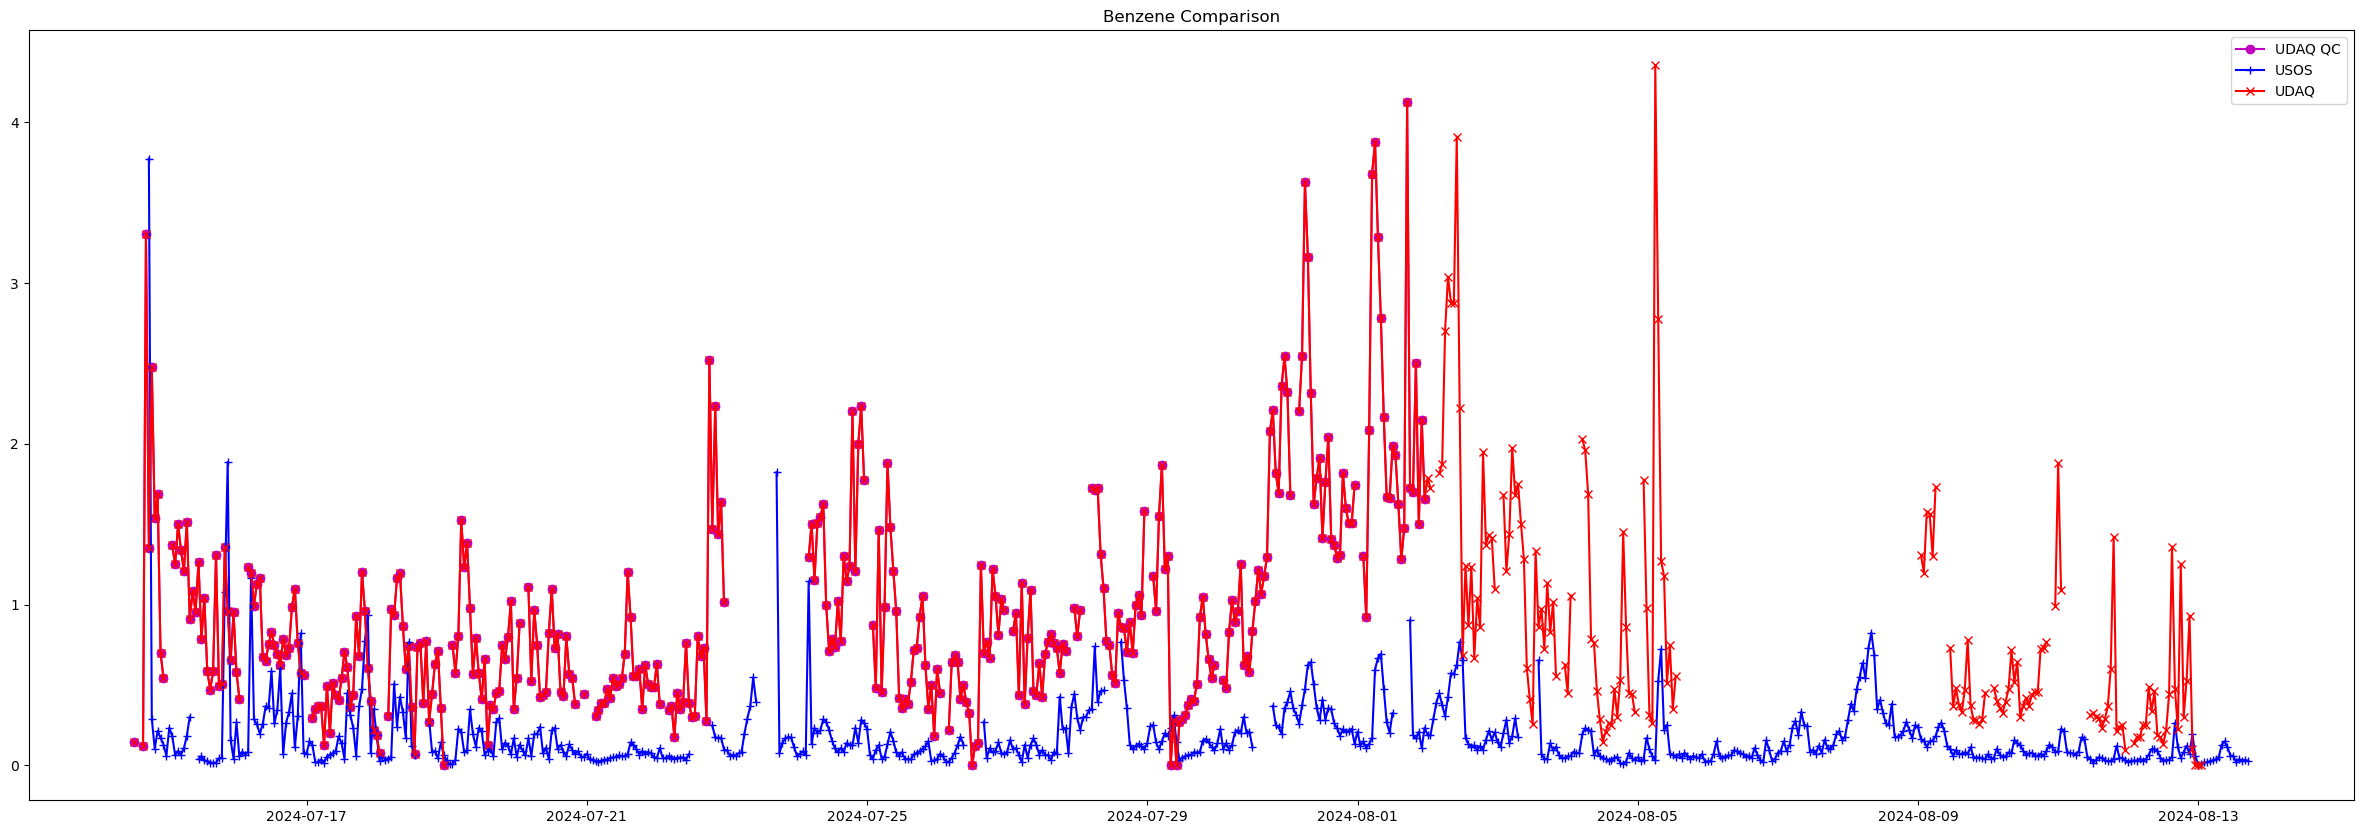

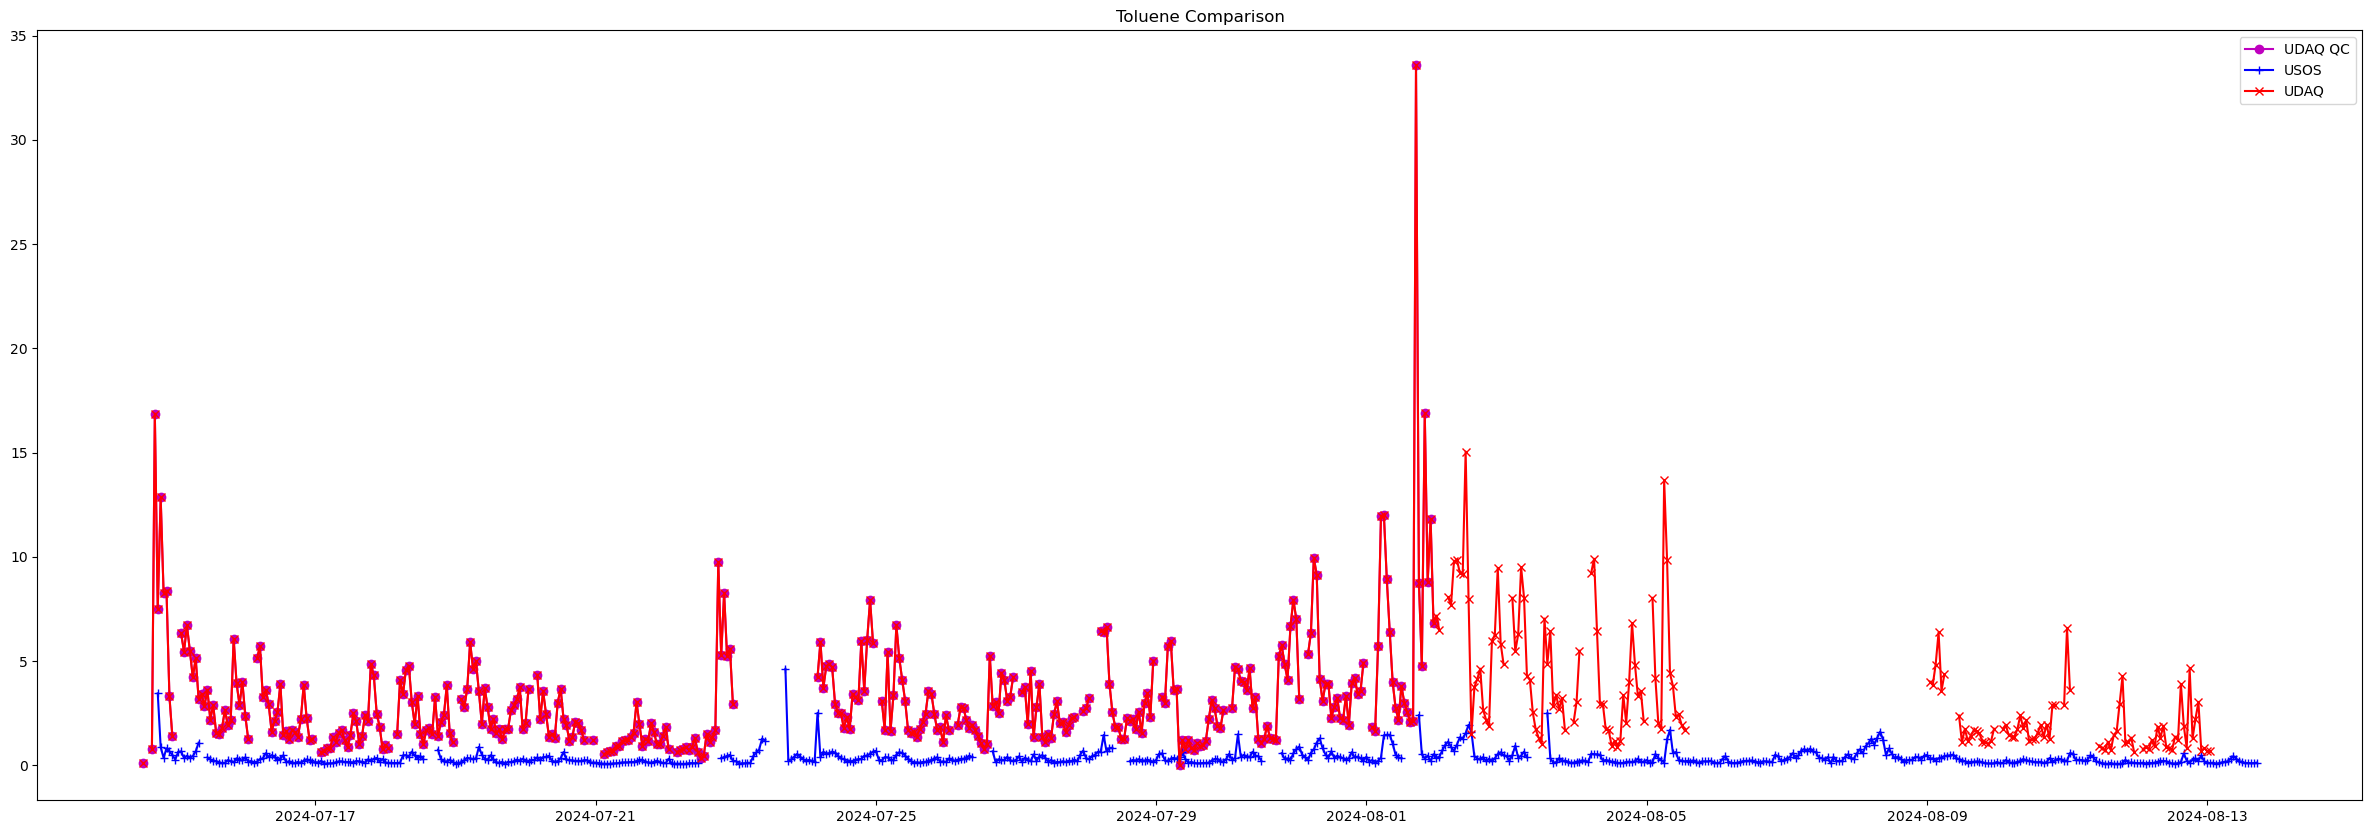

In [127]:
for species in range(0,3):
    # Plot it so we can take a look at it... 
    fig, ax = plt.subplots(figsize = (30,10))
    plt.plot(df_reshaped_udaq_species_qc.index, df_reshaped_udaq_species_qc[parameter_codes_needed[species]], color = 'm', marker = 'o', label = 'UDAQ QC')
    plt.plot(df_alldays.index, df_usos_species_locate[df_usos_species_needed[species]], color='b', marker='+',label='USOS')
    plt.plot(df_reshaped_udaq_species.index, df_reshaped_udaq_species[parameter_codes_needed[species]], color='r', marker='x', label='UDAQ')
    plt.legend()
    plt.title(species_names[species] + ' Comparison')
    # df_reshaped_hawthorne_species.columns.name = None

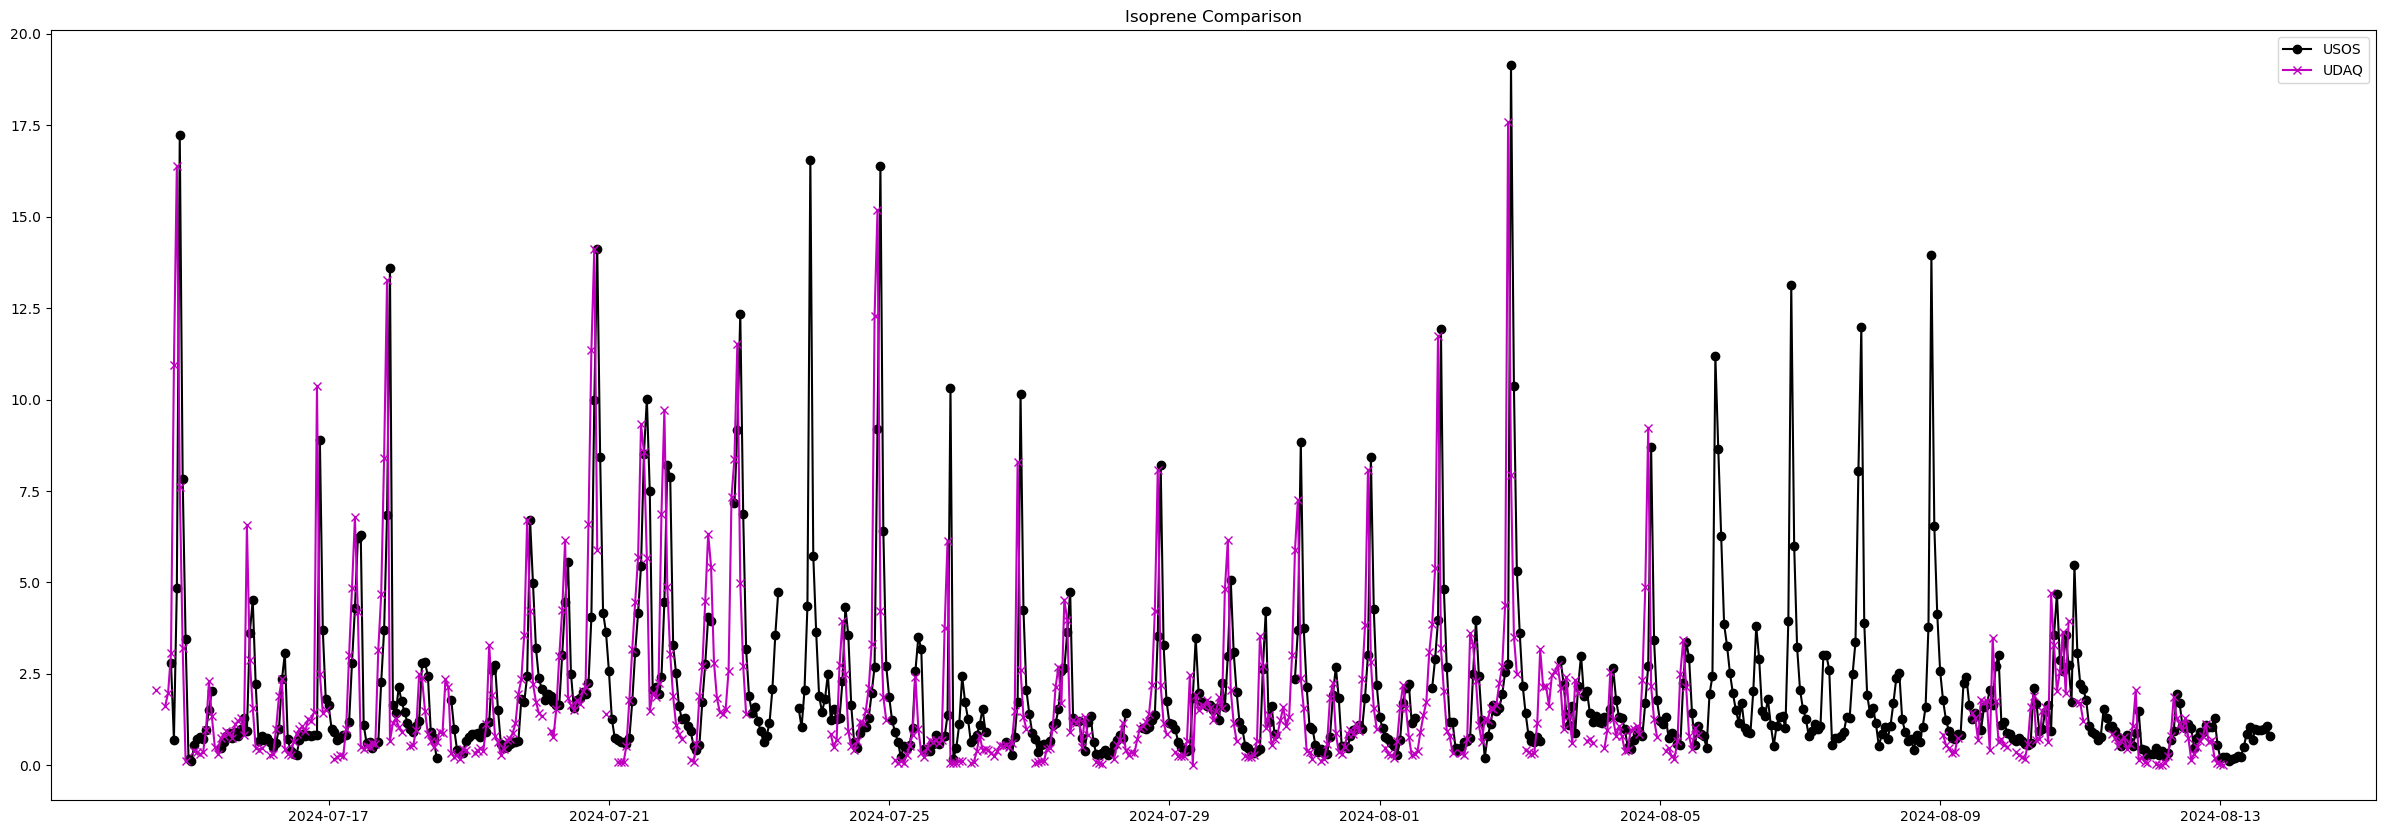

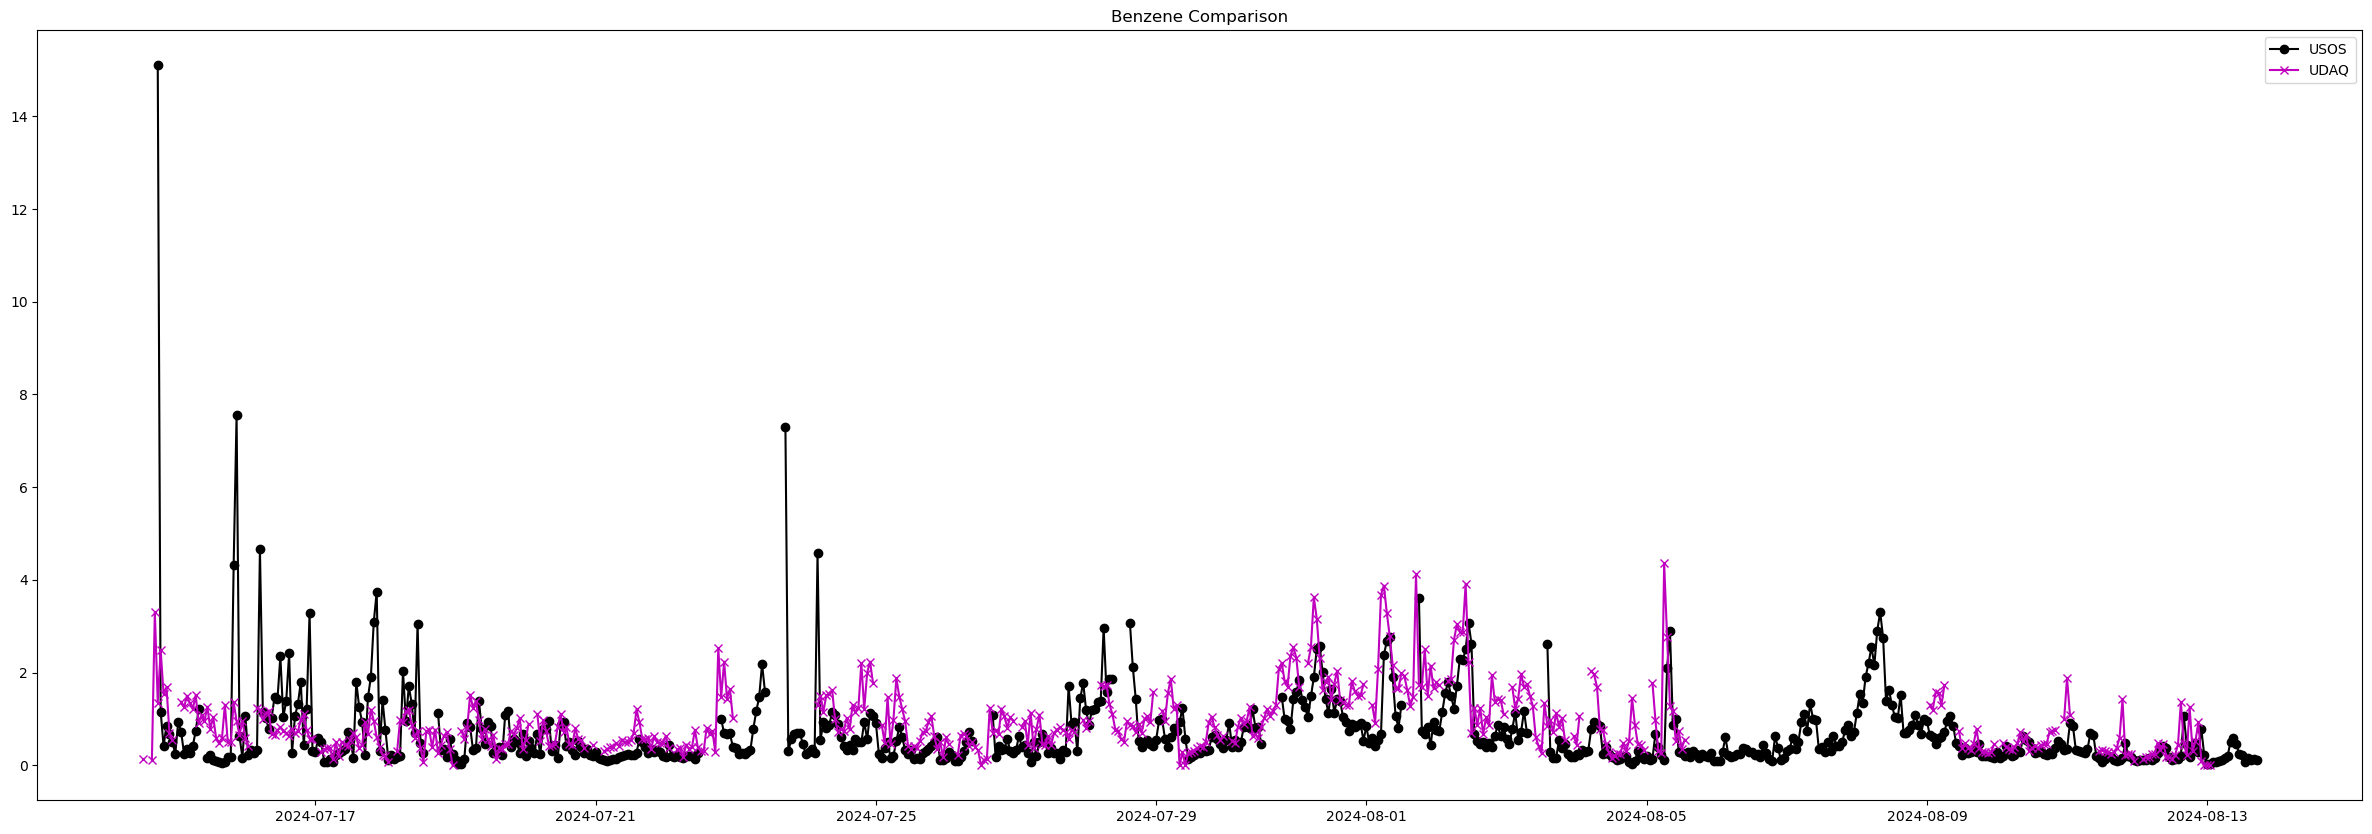

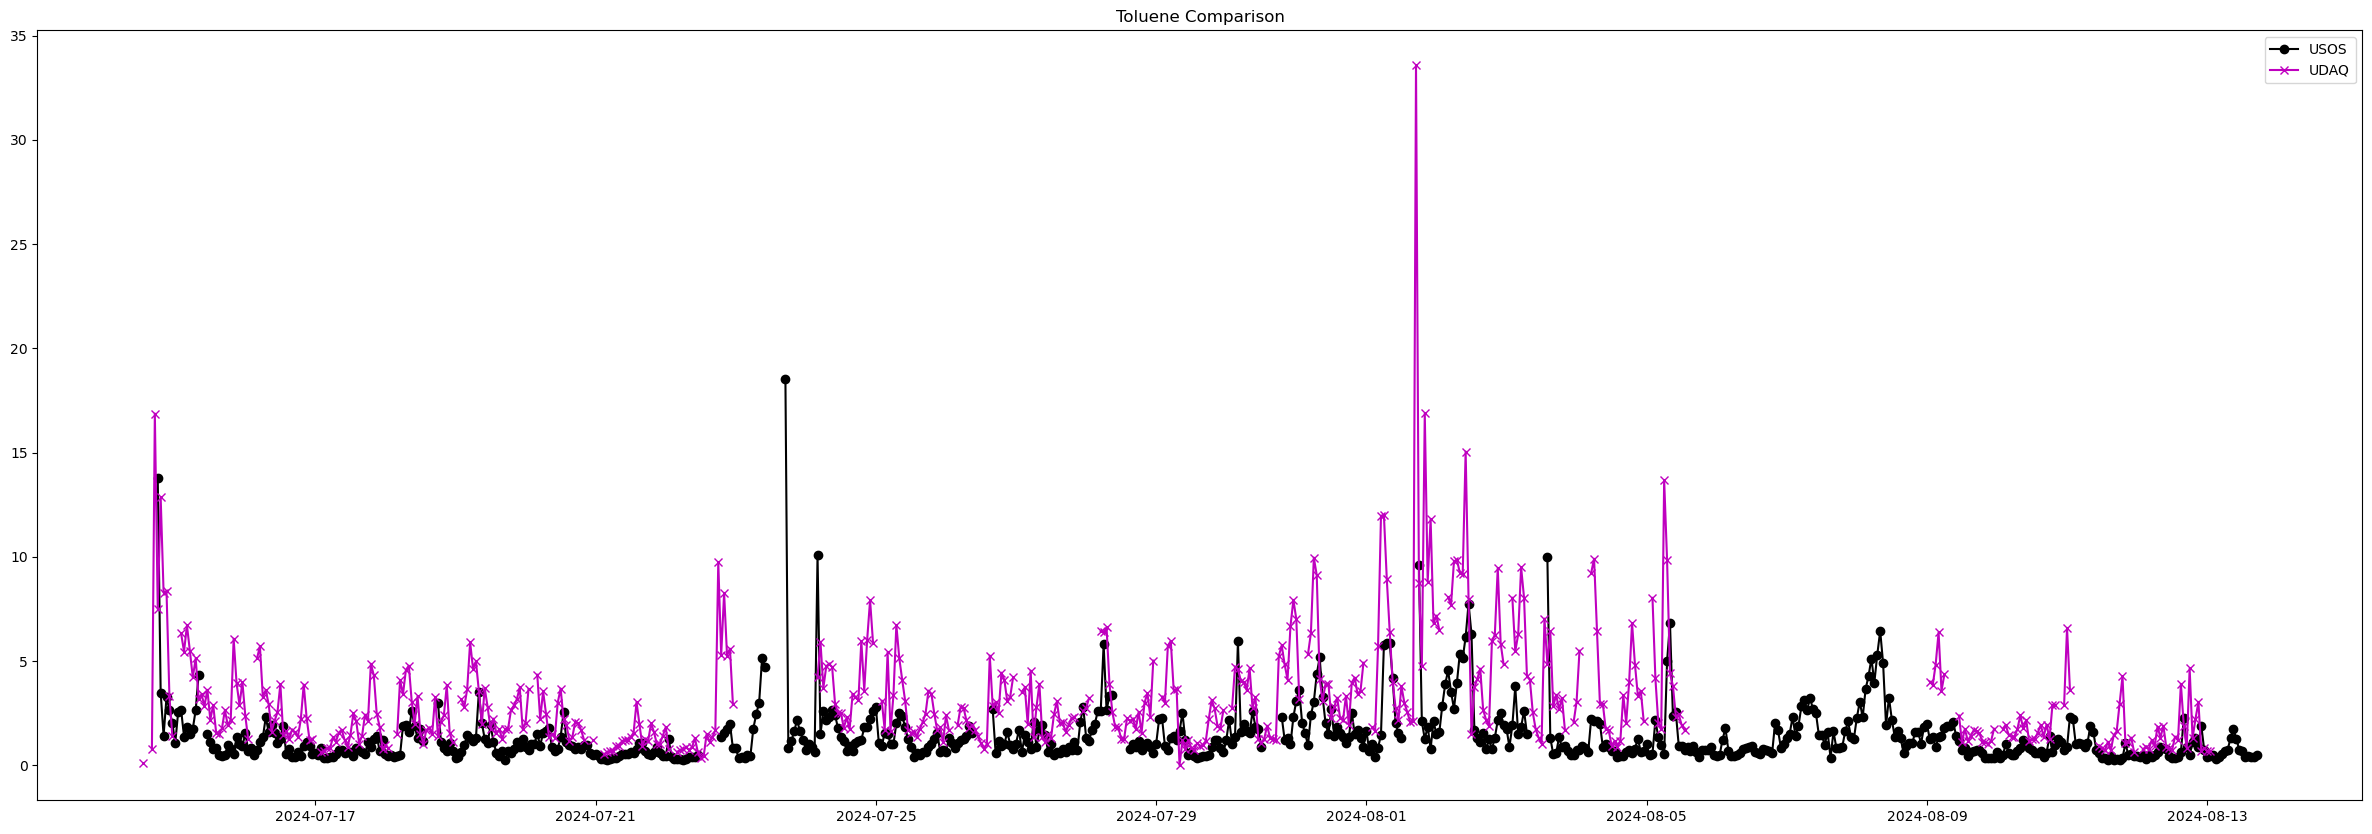

In [50]:
for species in range(0,3):
    # Plot it so we can take a look at it... 
    fig, ax = plt.subplots(figsize = (30,10))
    plt.plot(df_alldays.index, df_usos_species_locate[df_usos_species_needed[species]]*4, color='k', marker='o',label='USOS')
    plt.plot(df_reshaped_udaq_species.index, df_reshaped_udaq_species[parameter_codes_needed[species]], color='m', marker='x', label='UDAQ')
    plt.legend()
    plt.title(species_names[species] + ' Comparison')
    # df_reshaped_hawthorne_species.columns.name = None